# Eastern Arabian Sea air–sea $CO_2$ flux (SK-322/GC-02)

Site 15.01°N, 72.44°E, 517 m. Core top 0–160 cm, ~0–51 kyr.

My thesis stopped at the gradient, $\Delta p\mathrm{CO_2} = p\mathrm{CO_2^{sw}} - p\mathrm{CO_2^{atm}}$, which only tells you the direction (source vs sink) and the driving pressure in µatm. The actual flux of carbon across the sea surface (Wanninkhof, 2014 and Sarmiento and Grober, 2006) also needs the gas-transfer velocity (wind-driven) and the $CO_2$ solubility (temperature-driven):

$$F = k(U_{10},\,\mathrm{SST}) \; \cdot \; K_0(\mathrm{SST},S) \; \cdot \; \Delta p\mathrm{CO_2}$$

<!--this above equation is taken from Ocean Biogeochemical Dynamics (Sarmiento and Grober 2006) as well as Zeebe & Wolf-Gladrow (2001)-->

So the three things this notebook wires together are **SST** (have it, from Mg/Ca),
**wind speed** (from the PMIP models), and **$\Delta p\mathrm{CO_2}$** (construct $p\mathrm{CO_2^{sw}}$ from boron; atmospheric values comes from ice cores).

Let me explain each variable in detail: 

- $K_0(\mathrm{SST},S)$ is solubility, or howt much $CO_2$ seawater can hold on to at a given temperature/salinity. Cold water tends to hold more. 

- $k(U_{10},\,\mathrm{SST})$ is the gas transfer velocity, or how fast the gas crosses the air-sea interface. This is largely determined by wind. 

- $\Delta p\mathrm{CO_2}$ is the pressure difference driving the gas through the surface. A positive value means that the ocean wishes to "breathe" out $CO_2$. 

Everything below is indexed on depth, not age. The age model is being revised,
so depth is the master axis for now; the age column is carried along but treated as provisional.
Swapping to the age axis later is a change that will be made after the age model is constructed.

## 1. Loading  the data

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sk322_data.csv') #pandas dataframe aka table created
df = df.sort_values('depth_cm').reset_index(drop=True) #sorted by depth, index is reset (precaution if input csv is not already sorted by depth)
df.head(4) #shows first 4 rows of the table

,depth_cm,age_kyr,mg_ca,sst_c,d11b,ph,pco2_sw
0,13.0,6.599,4.848,28.852,21.128,8.255,228.364
1,16.0,8.122,4.611,28.536,21.613,8.292,203.989
2,19.0,9.645,4.793,29.441,21.998,8.309,192.927
3,22.0,11.168,4.684,28.929,21.869,8.306,195.385


Note on the data: the `age_kyr` column is the two-point radiocarbon age model from the thesis, and the age model is being redone.

## 2. Plots vs depth

A look at the raw inputs plotted against depth. 

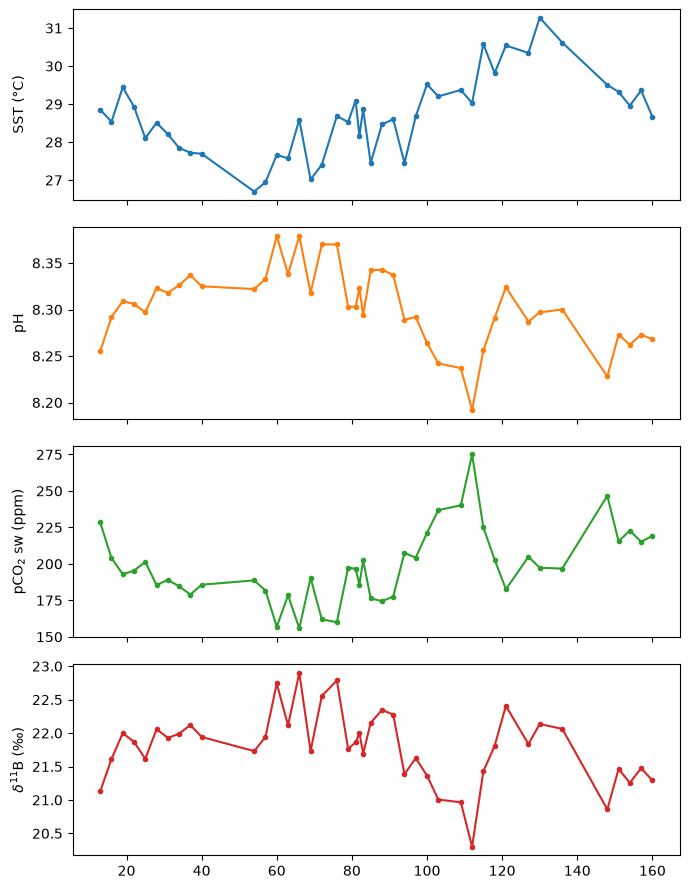

In [9]:
fig, ax = plt.subplots(4, 1, figsize=(7, 9), sharex=True)  #plt is matplotlib.pyplot, ax is an array of 4 axes objects (subplots), sharex means they share the same x-axis

ax[0].plot(df.depth_cm, df.sst_c, marker='o', ms=3)
ax[0].set_ylabel('SST (°C)')

ax[1].plot(df.depth_cm, df.ph, marker='o', ms=3, color='C1') #C1 is a color in the default matplotlib color cycle
ax[1].set_ylabel('pH')

ax[2].plot(df.depth_cm, df.pco2_sw, marker='o', ms=3, color='C2')
ax[2].set_ylabel('pCO$_2$ sw (ppm)')

ax[3].plot(df.depth_cm, df.d11b, marker='o', ms=3, color='C3')
ax[3].set_ylabel(r'$\delta^{11}$B (‰)') #the r before the string indicates that it is a raw string, which is useful as LaTeX formatting uses it a lot and you don't have to escape backslashes in matplotlib

fig.align_ylabels(ax) #the y axis labels all lie on the same vertical line, so they are aligned
fig.tight_layout() #the layout of the figure is adjusted so that the subplots fit into the figure area nicely

## 3. Gas-exchange physics

Four small functions, each one equation from the literature. 

**Solubility** $K_0$ — Weiss (1974). How much CO₂ seawater can hold per unit partial pressure; colder water holds more.

$$\ln K_0 = -60.2409 + 93.4517\left(\tfrac{100}{T}\right) + 23.3585\ln\!\left(\tfrac{T}{100}\right) + S\left[0.023517 - 0.023656\left(\tfrac{T}{100}\right) + 0.0047036\left(\tfrac{T}{100}\right)^2\right]$$

$T$ in Kelvin, $S$ in PSU. Units: mol kg⁻¹ atm⁻¹.

**Schmidt number** $Sc$ — Wanninkhof (2014). A dimensionless ratio (seawater viscosity ÷ CO₂ diffusivity) describing how readily CO₂ diffuses at a given temperature. This is the route by which *temperature* enters the transfer velocity:

$$Sc = 2116.8 - 136.25\,T + 4.7353\,T^2 - 0.092307\,T^3 + 0.0007555\,T^4$$

$T$ in °C. The reference value 660 (used below) is CO₂ in seawater at 20 °C.

**Transfer velocity** $k$ — Wanninkhof (2014). How fast gas crosses the interface: driven by wind (the $u^2$ term) and rescaled for temperature via $Sc$:

$$k = 0.251\,\langle u_{10}^2\rangle\left(\frac{Sc}{660}\right)^{-1/2}$$

$k$ in cm hr⁻¹, $u_{10}$ in m s⁻¹. The $(Sc/660)^{-1/2}$ factor normalises $k$ to the reference gas/temperature — warmer water → lower $Sc$ → faster transfer.

**Flux** — combine them:

$$F = k \cdot K_0 \cdot \Delta p\mathrm{CO_2}$$

Positive = ocean outgassing (source), matching the thesis sign. It's rate ($k$) × capacity ($K_0$) × driving pressure ($\Delta p\mathrm{CO_2}$).

In [10]:
from flux_physics import co2_solubility, schmidt_co2, gas_transfer_velocity, co2_flux

### Sanity checks — sourced

Each target below is a published value, not a remembered one. Verify against the
cited table in Sarmiento & Gruber (2006), Chapter 3:

- **K₀(28 °C) ≈ 0.026 mol/kg/atm** (27.0 mol/m³/atm after ×ρ). Cross-check: Table 3.2.3
  lists CO₂ solubility as 28,970 (25 °C) and 25,650 (30 °C) mmol m⁻³ atm⁻¹; interpolating
  to 28 °C gives ~26,980, matching ours to 0.2%. Original source: Weiss (1974).
- **Sc(28 °C) ≈ 451–452.** Table 3.3.1 gives the CO₂ Schmidt coefficients (1992, 4-term form).
  This code uses the Wanninkhof (2014) 5-term form; the two agree to 0.3% at 28 °C.
- **k(6 m/s, 28 °C) ≈ 11 cm/hr.** Table 3.3.2 lists global-mean k of 10.2–17.3 cm/hr across
  models; 6 m/s is a modest wind, so the low end is expected. 
- **F ≈ 1.3 mol m⁻² yr⁻¹** at ΔpCO₂ = 50 µatm — the product of the three above; an internal
  consistency check, not an independently published number.

In [ ]:
print('K0(28°C)     ', round(float(co2_solubility(28)), 5), 'mol/kg/atm  (~0.026)')
print('Sc(28°C)     ', round(float(schmidt_co2(28)), 1), '            (~450)')
print('k(6 m/s,28°C)', round(float(gas_transfer_velocity(6, 28)), 2), 'cm/hr       (~11)') # 6 is taken as a placeholder value
print('F(6,28,50)   ', round(float(co2_flux(6, 28, 50)), 3), 'mol/m2/yr   (~1.3)')

K0(28°C)      0.02638 mol/kg/atm  (~0.026)
Sc(28°C)      452.3             (~450)
k(6 m/s,28°C) 10.91 cm/hr       (~11)
F(6,28,50)    1.293 mol/m2/yr   (~1.3)


## 4. Wind speed and atmospheric $CO_2$, the two inputs held constant for now

- **`U10`** - Multi-model PMIP4 LGM output (AWI-ESM-1-1-LR,
  INM-CM4-8, MPI-ESM1-2-LR) was extracted at the site, correcting for coastal contamination
  in the nearest grid cell by sampling an open-ocean cell instead (~2.5 deg west). This gives
  **6.86 +/- 0.52 m/s** as the LGM estimate (from pmip_wind.ipynb). It's applied here as a single constant across the
  whole record once the age model lands, this becomes age-dependent (LGM-aged samples get
  this value, other ages get their own PMIP-derived or modern estimate) rather than one number
  applied everywhere.
  
- **`pco2_atm`**  still a placeholder constant. The real value comes from the Vostok/composite
  ice core (Lüthi et al. 2008), the same source the thesis used, but it lives on the age axis
  and can only be aligned to our samples once the revised age model lands. Until then, a single constant lets the flux calculation run end-to-end without blocking on that.

In [ ]:
U10 = 6.86            # m/s   TODO: replace with averaged PMIP data depending on exact age
U10_std = 0.52
pco2_atm = 190.0     # ppm   TODO: replace with age-aligned ice-core CO2 (glacial ~190, Holocene ~270)

df['delta_pco2'] = df['pco2_sw'] - pco2_atm
df['flux'] = co2_flux(U10, df['sst_c'], df['delta_pco2'])
df['flux_low']  = co2_flux(U10 - U10_std, df['sst_c'], df['delta_pco2'])
df['flux_high'] = co2_flux(U10 + U10_std, df['sst_c'], df['delta_pco2'])
df[['depth_cm', 'sst_c', 'pco2_sw', 'delta_pco2', 'flux']].head()


,depth_cm,sst_c,pco2_sw,delta_pco2,flux
0,13.0,28.852,228.364,38.364,1.296942
1,16.0,28.536,203.989,13.989,0.472825
2,19.0,29.441,192.927,2.927,0.098997
3,22.0,28.929,195.385,5.385,0.182056
4,25.0,28.104,201.354,11.354,0.383690


## Plotting the calculated flux value 

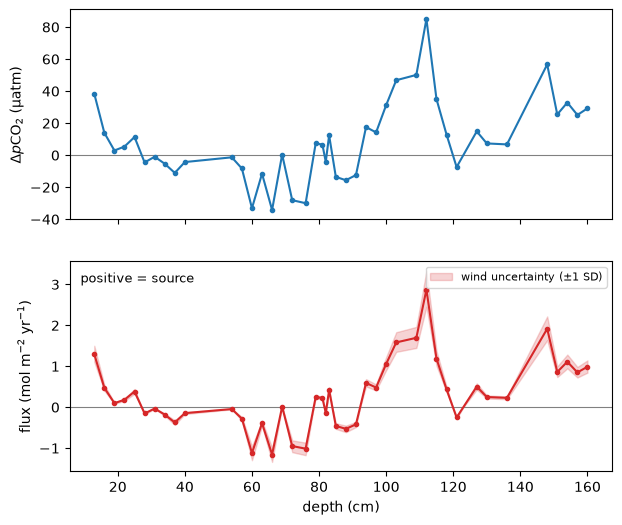

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

ax[0].axhline(0, color='grey', lw=0.8)
ax[0].plot(df.depth_cm, df.delta_pco2, marker='o', ms=3)
ax[0].set_ylabel(r'$\Delta p$CO$_2$ (µatm)')

ax[1].axhline(0, color='grey', lw=0.8)
ax[1].fill_between(df.depth_cm, df.flux_low, df.flux_high, color='C3', alpha=0.2, label='wind uncertainty (±1 SD)')
ax[1].plot(df.depth_cm, df.flux, marker='o', ms=3, color='C3')
ax[1].set_ylabel('flux (mol m$^{-2}$ yr$^{-1}$)')
ax[1].set_xlabel('depth (cm)')
ax[1].text(0.02, 0.9, 'positive = source', transform=ax[1].transAxes, fontsize=9)
ax[1].legend(loc='upper right', fontsize=8)

#fig.tight_layout()

## 5. Next steps (in order)

1. **Age axis.** When the revised age model arrives, I will add an `age_kyr_v2` column and  plot against that instead of `depth_cm`. 
2. **Real atmospheric CO$_2$.** I wll load the ice-core series, interpolate it onto sample ages, and replace the `pco2_atm` constant. 
3. **Real wind.** PMIP Paleo wind gridded data (LGM and Mid Holocene) which can be plugged in after the age model (pmip_wind.ipynb).
4. **Modern-day validation (in progress)** Before trusting the flux calculation on 50,000-year-old paleo data, I will check it against the present day, where the answer is already known.

I will build a small gridded map of modern SST, wind, and pCO2 around
the site, run it through the same flux physics, and compare the result to the
published modern Arabian Sea CO2 source (~90 Tg-C/yr, Takahashi et al. 1997, 2009).
If the physics reproduces the known modern number, the same machinery can be trusted
running backwards in time.

**Data sources:** WOA23 (SST) and Takahashi (2009, surface pCO2) are the primary
inputs currently planned; GLODAP is also being considered. Wind from CCMP or ERA5. Exact combination still being finalized.


## Reconciling site flux (mol/m2/yr) with Takahashi's basin total (Tg-C/yr)

These are two different kinds of quantity, not two competing answers to the same question.

This notebook's flux (mol m^-2 yr^-1) is a per-area rate, computed at one specific point (SK-322). It describes how much CO2 crosses each square metre of sea surface per year at that location.

Takahashi's approximately 90 Tg-C/yr is a whole-basin integrated total: the per-area rate already multiplied by the entire Arabian Sea's surface area and summed. It describes total CO2 emitted by the whole basin per year.

Conversion: spreading Takahashi's 90 Tg-C/yr evenly over the Arabian Sea's area (approximately 3.86 million km^2) gives an equivalent average rate:

    90e12 g/yr / 12.011 g/mol / 3.86e12 m^2 = approximately 1.94 mol/m^2/yr

This value falls within this notebook's flux range (approximately -1 to 2.2 mol/m^2/yr), with several peak values close to 1.94 directly. The site's per-area numbers are the correct order of magnitude and consistent with the published basin average.

## Parameters held constant, but could be made variable

This notebook fixes several quantities as scalars. Each could become a per-sample
column (depth- or age-varying) to make the reconstruction more complete. 

1. **Wind speed U10**: fixed modern now, will be made variable via
   PMIP model winds (LGM/mid-Holocene slices) or a grain-size-proxy scaling once age model is redone. 
2. **Atmospheric pCO2**: becomes variable automatically once the ice-core interpolation
   is wired in, again after the age model.
3. **Salinity (SSS)**: fixed at 35 PSU. Varies with monsoon freshwater input and
   ice-volume/sea-level. Feeds K0, Sc, the boron/carbon constants, and pCO2-from-pH.
4. **Total alkalinity (TA)**: fixed at modern. Varies with salinity and ice volume,
   justified holding it via Hönisch et al. (2009).
5. **Seawater density ρ**: fixed at 1025. Varies weakly with T and S, a minor effect.